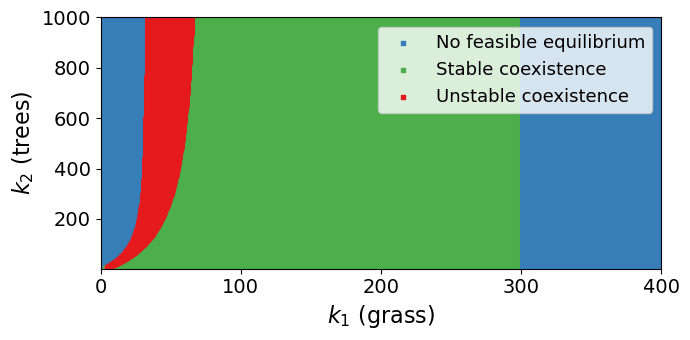

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
A = 1.5
B1 = 0.45
B2 = 0.05
F = 0.11
H = 0.11

#Finds the coexistence equilibria
def find_coexistence_equilibria(k1, k2, A, B1, B2, F, H):
    alpha = k2*(F*B1 - B2)/(F*B1)
    beta = k2*B2/(F*B1*k1)
    
    a_coeff = B1*(1+beta)*(1+H*beta) + A*(1+H*beta)/k1
    b_coeff = B1*alpha*(1+H*beta) + B1*H*alpha*(1+beta) - A*(1+H*beta) + A*H*alpha/k1
    c_coeff = B1 + B1*H*alpha**2 - A*H*alpha
    
    discriminant = b_coeff**2 - 4*a_coeff*c_coeff
    
    if discriminant < 0:
        return None
    
    u1_plus = (-b_coeff + np.sqrt(discriminant))/(2*a_coeff)
    u1_minus = (-b_coeff - np.sqrt(discriminant))/(2*a_coeff)
    
    for u1 in [u1_plus, u1_minus]:
        u2 = alpha + beta*u1
        if u1 > 0 and u2 > 0 and u1 < k1 and u2 < k2:
            w = A/(1 + (u1+u2)*(u1+H*u2))
            if w > 0:
                return (u1, u2, w)
    return None

#Computes the eigenvalue of the fixed point evaluated at the Jacobian
def compute_jacobian_eigenvalues(u1, u2, w, k1, k2, B1, B2, F, H):
    S = u1 + H*u2
    T = u1 + u2
    
    J11 = w*S*(1-u1/k1) + w*u1*(1-u1/k1) - w*u1*S/k1 - B1
    J12 = w*u1*H*(1-u1/k1)
    J13 = u1*S*(1-u1/k1)
    J21 = F*w*u2*(1-u2/k2)
    J22 = F*w*S*(1-u2/k2) + F*w*u2*H*(1-u2/k2) - F*w*u2*S/k2 - B2
    J23 = F*u2*S*(1-u2/k2)
    J31 = -w*S - w*T
    J32 = -w*H*T - w*S
    J33 = -1 - T*S
    
    J = np.array([[J11, J12, J13],
                   [J21, J22, J23],
                   [J31, J32, J33]])
    return np.linalg.eigvals(J)

#Fine grid
k1_values = np.linspace(2, 400, 1000)
k2_values = np.linspace(2, 1000, 1000)

stable_k1, stable_k2 = [], []
unstable_k1, unstable_k2 = [], []
no_equil_k1, no_equil_k2 = [], []

for k1 in k1_values:
    for k2 in k2_values:
        equil = find_coexistence_equilibria(k1, k2, A, B1, B2, F, H)
        
        if equil is None:
            no_equil_k1.append(k1)
            no_equil_k2.append(k2)
            continue
        
        u1, u2, w = equil
        eigs = compute_jacobian_eigenvalues(u1, u2, w, k1, k2, B1, B2, F, H)
        
        if all(np.real(eigs) < 0):
            stable_k1.append(k1)
            stable_k2.append(k2)
        else:
            unstable_k1.append(k1)
            unstable_k2.append(k2)

fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
ax.scatter(no_equil_k1, no_equil_k2, c='#377eb8', s=8, marker='s', label='No feasible equilibrium')
ax.scatter(stable_k1, stable_k2, c='#4daf4a', s=8, marker='s', label='Stable coexistence')
ax.scatter(unstable_k1, unstable_k2, c='#e41a1c', s=8, marker='s', label='Unstable coexistence')

ax.set_xlabel('$k_1$ (grass)', fontsize=16)
ax.set_ylabel('$k_2$ (trees)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=13, loc='upper right')
ax.set_xlim(2, 400)
ax.set_ylim(2, 1000)
ax.set_xticks(np.arange(0, 401, 100))
plt.tight_layout()
plt.savefig('coexistence_stability_plane.pdf', format='pdf', bbox_inches='tight')
plt.show()